# XAI Implementation with SHAP
##### Reference to all related LR, and senior progress report 
##### 👉 https://grove-wish-6a4.notion.site/Literature-Review-for-XAI-Abdulla-16a044f5ae6480eaabf8ef223735ff37?pvs=4
---

##### Necessary Imports for the entire program

In [3]:
# - Data Manipulation and Preprocessing
import pandas as pd         # For handling datasets and data manipulation
import numpy as np          # For manipulating numeric values

# - Model Building

# For splitting data 
from sklearn.model_selection import train_test_split 

from sklearn.metrics import (
    accuracy_score         # For evaluating model accuracy
)

# - Machine Learning Models
from sklearn.ensemble import RandomForestClassifier  # For Random Forest Classifier


# - Visualization
import plotly.express as px                          # For simple, expressive plotting
import matplotlib.pyplot as plt                      # For plotting static visualizations


# - XAI Implementation
import shap                                          # For Implementing SHAP

##### <u>**Loading and viewing the dataset**</u> 

In [4]:
data = pd.read_csv("selected_genes_500_xg.csv")

data

,FNTA,RPL13A,PRKAB2,LMAN1,PLEKHH3,FOXG1,LENEP,PLEKHM1,ZNF331,WASL,...,LEPR,VIPR1,ABCG5,CTBS,PDGFRA,CHST4,ATP5D,DNAJB14,BMP5,Symbol
0,11.297200,14.966000,9.498130,11.731300,8.305770,1.792970,0.896011,8.758000,8.418010,10.680500,...,12.408900,8.841790,12.072300,9.920940,7.784400,7.641680,12.830600,9.134580,7.305270,sl
1,10.824800,15.117000,9.571150,12.398000,8.823390,1.098990,0.893618,10.087700,8.781200,10.650500,...,12.392500,9.896900,10.825600,9.973580,11.152900,9.628030,13.010900,9.605040,6.587220,sl
2,10.847800,15.094800,9.205950,12.905100,9.021860,1.319160,1.255240,9.610530,8.872160,10.418000,...,13.242800,9.736940,11.017900,10.080300,10.780300,9.974950,13.633200,9.173220,6.502350,sl
3,11.285000,14.872900,9.351100,12.919500,8.443840,1.100720,0.894844,10.030300,8.592660,10.404600,...,11.796800,8.841690,11.536800,10.152500,10.192600,8.131270,13.023700,9.565130,6.501770,sl
4,10.645000,15.358600,9.070840,12.444800,9.259130,1.100160,0.894447,9.695740,9.565850,10.493300,...,11.735800,9.612080,11.527200,9.530410,9.555440,7.438170,13.925600,8.122950,5.065310,sl
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
765,10.030643,10.583749,8.462638,6.637312,7.195148,5.885801,5.706954,7.158889,7.005923,10.334260,...,10.352682,10.481065,8.078393,9.370270,9.867904,10.228107,11.749861,7.901930,7.006292,sl
766,9.308484,9.460258,8.212136,6.179422,7.275672,5.641487,5.902423,7.327063,7.062386,9.907153,...,8.157884,10.154319,8.856472,9.719864,7.500607,6.190256,12.398339,8.159077,5.920143,ehcc
767,9.780593,10.147125,9.188711,6.602732,7.006846,6.031874,5.711407,7.464194,6.388256,10.064824,...,9.898550,8.987347,9.684653,9.120302,6.932221,6.122836,11.882567,8.048209,6.116673,ehcc
768,9.818722,9.747493,8.596682,6.701066,7.712645,5.956010,5.893906,7.203791,7.014167,10.614054,...,8.782304,9.409681,8.287098,9.899270,7.671989,6.321199,11.999193,7.937260,6.201666,ehcc


##### <u>**Removal of duplicates**</u>

In [5]:
duplicates = data.duplicated()
print("Duplicate rows present in our liver cancer dataset:")
print(data[duplicates])

data = data.drop_duplicates()

print("Our dataframe object after removing duplicates:")
print(data)

Duplicate rows present in our liver cancer dataset:
Empty DataFrame
Columns: [FNTA, RPL13A, PRKAB2, LMAN1, PLEKHH3, FOXG1, LENEP, PLEKHM1, ZNF331, WASL, PALM, MMRN2, UPF3B, HK1, CADPS, KLRB1, ARMCX4, IGF2BP3, TMEM158, EXOC3, TJP2, MICA, HNRNPAB, CRADD, CCR1, ABCD1, OLFML1, OTUD3, PRKAR1B, AQP6, FLCN, YBX2, NTSR2, ABCC3, EPYC, WDR43, TBX5, TIMM10, DLEC1, RIN3, ACTL6A, NOL8, MCFD2, RNASET2, PRPF4B, PTPRM, CASR, RANBP2, ABCD4, SMARCD2, PPP2R5C, RAD54L, GABARAPL2, IRF9, FNBP1, SLC1A1, SYNGR3, ZBTB43, AOAH, ATP6V0D1, MAL, CYP4F3, MPP1, SCNN1D, ZNF385D, ZXDA, ZNF362, ZNF415, TEX2, GALNT4, CACNA1A, PODXL2, MYC, WDR91, TNFSF12, CRKL, MAP2K7, TUBB3, NDUFB4, ZBTB39, MARCKS, USP48, KLHDC8A, ARTN, LMAN1L, TM6SF1, ANKHD1-EIF4EBP3, LRRC31, ARPC5, PA2G4, TOP3B, MBD4, FAM49A, STC1, SLC22A4, TOM1L1, KNTC1, POMZP3, MEP1A, PDCD6IP, ...]
Index: []

[0 rows x 501 columns]
Our dataframe object after removing duplicates:
          FNTA     RPL13A    PRKAB2      LMAN1   PLEKHH3     FOXG1     LENEP  \
0    11.

#### We can notice that there were no duplicate rows amongst our dataset

##### Let's observe a general description of the data

In [6]:
data.describe()

,FNTA,RPL13A,PRKAB2,LMAN1,PLEKHH3,FOXG1,LENEP,PLEKHM1,ZNF331,WASL,...,TSPAN7,LEPR,VIPR1,ABCG5,CTBS,PDGFRA,CHST4,ATP5D,DNAJB14,BMP5
count,770.000000,770.000000,770.000000,770.000000,770.000000,770.000000,770.000000,770.000000,770.000000,770.000000,...,770.000000,770.000000,770.000000,770.000000,770.000000,770.000000,770.000000,770.000000,770.000000,770.000000
mean,9.830529,11.386738,6.632759,6.650699,4.147177,3.502188,4.729801,5.931961,7.461844,8.076463,...,6.821512,6.564034,6.478701,8.914742,7.516251,7.166102,5.708625,8.084441,7.666284,3.623757
std,0.849492,1.070341,1.372231,1.707957,1.543616,1.449236,0.994949,0.988004,1.535125,1.574285,...,1.096398,2.285055,1.391966,1.871927,1.293298,2.540508,1.861424,1.741504,0.977664,1.439751
min,6.503775,8.458377,2.820605,2.475998,2.086013,1.092670,0.889150,4.041178,3.260362,3.738651,...,3.195900,2.346697,2.880102,2.854717,4.006609,2.116066,2.802143,5.835703,4.043386,1.567429
25%,9.304760,10.741000,5.714509,5.792298,3.299575,2.824644,4.325317,5.394093,6.392302,7.150717,...,6.082886,4.926110,5.690263,8.153266,6.780238,4.828880,4.428785,7.096043,7.271608,2.632070
50%,9.853110,11.418217,6.483085,6.640908,3.642899,3.081715,4.894539,5.605948,7.510724,8.088382,...,6.847724,6.179373,6.203456,9.251357,7.623716,7.377411,5.000871,7.606091,7.823369,2.969673
75%,10.318969,11.918522,7.401941,7.378960,4.228279,3.928156,5.342103,6.027815,8.507082,9.109302,...,7.611388,7.996107,6.962566,10.076888,8.318910,8.914388,6.844163,8.041807,8.181409,4.566655
max,12.360497,15.541100,11.198500,13.248300,10.846400,10.713577,6.866125,10.223200,11.552221,11.618500,...,10.037737,13.530900,11.280150,13.029400,10.959600,12.315176,12.168509,14.277900,10.441366,7.339790


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 770 entries, 0 to 769
Columns: 501 entries, FNTA to Symbol
dtypes: float64(500), object(1)
memory usage: 2.9+ MB


##### <u>**Checking null values using `isnull()` function**</u>

In [8]:
data.isnull().sum()

FNTA       0
RPL13A     0
PRKAB2     0
LMAN1      0
PLEKHH3    0
          ..
CHST4      0
ATP5D      0
DNAJB14    0
BMP5       0
Symbol     0
Length: 501, dtype: int64

##### **Filtering of null values using `fillna()` function**

```python
df.fillna(0, inplace=True) # For replacing NaN values with 0

In [9]:
data.fillna(0, inplace=True)

# Check for any null values still exists in the dataset
null_counts = data.isnull().sum()
print(null_counts[null_counts > 0])

Series([], dtype: int64)


##### No null values, we get an empty array.

##### <u>**Re-encoding Labels for Classification**</u>

##### (From the senior group)

In [10]:
target = data["Symbol"].map({
    "sl": 0,
    "hgdn": 1,
    "lgdn": 2, 
    "ehcc": 3, 
    "phcc": 4
})

##### **Note that we didn't keep the old Category labels in order to avoid redundancy**

#### <u> **Encoded Labels Mapping** </u>
- **`sl`** → `0`
- **`hgdn`** → `1`
- **`lgdn`** → `2`
- **`ehcc`** → `3`
- **`phcc`** → `4`

This is to showcase the order of mapping that was done after the encoding process


### <u> **Univariant Analysis** </u>

In [11]:
data.Symbol.value_counts()

Symbol
phcc    331
ehcc    305
lgdn     70
hgdn     38
sl       26
Name: count, dtype: int64

In [12]:
# Get unique values and counts for the bar chart
values = data['Symbol'].unique()
count = data['Symbol'].value_counts().to_list()


fig = px.bar( # bar-chart
    x=values,
    y=count,
    title='Values by Classes',
    labels={"x": "Class", "y": "Number of Cases"} 
)

fig.show()

#### **Preprocessing is complete, below is the preview of the new dataset acheived:**

[Note: we were asked to not implement any standardization as this can possibly hurt the medical nature of our dataset]

In [13]:
data

,FNTA,RPL13A,PRKAB2,LMAN1,PLEKHH3,FOXG1,LENEP,PLEKHM1,ZNF331,WASL,...,LEPR,VIPR1,ABCG5,CTBS,PDGFRA,CHST4,ATP5D,DNAJB14,BMP5,Symbol
0,11.297200,14.966000,9.498130,11.731300,8.305770,1.792970,0.896011,8.758000,8.418010,10.680500,...,12.408900,8.841790,12.072300,9.920940,7.784400,7.641680,12.830600,9.134580,7.305270,sl
1,10.824800,15.117000,9.571150,12.398000,8.823390,1.098990,0.893618,10.087700,8.781200,10.650500,...,12.392500,9.896900,10.825600,9.973580,11.152900,9.628030,13.010900,9.605040,6.587220,sl
2,10.847800,15.094800,9.205950,12.905100,9.021860,1.319160,1.255240,9.610530,8.872160,10.418000,...,13.242800,9.736940,11.017900,10.080300,10.780300,9.974950,13.633200,9.173220,6.502350,sl
3,11.285000,14.872900,9.351100,12.919500,8.443840,1.100720,0.894844,10.030300,8.592660,10.404600,...,11.796800,8.841690,11.536800,10.152500,10.192600,8.131270,13.023700,9.565130,6.501770,sl
4,10.645000,15.358600,9.070840,12.444800,9.259130,1.100160,0.894447,9.695740,9.565850,10.493300,...,11.735800,9.612080,11.527200,9.530410,9.555440,7.438170,13.925600,8.122950,5.065310,sl
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
765,10.030643,10.583749,8.462638,6.637312,7.195148,5.885801,5.706954,7.158889,7.005923,10.334260,...,10.352682,10.481065,8.078393,9.370270,9.867904,10.228107,11.749861,7.901930,7.006292,sl
766,9.308484,9.460258,8.212136,6.179422,7.275672,5.641487,5.902423,7.327063,7.062386,9.907153,...,8.157884,10.154319,8.856472,9.719864,7.500607,6.190256,12.398339,8.159077,5.920143,ehcc
767,9.780593,10.147125,9.188711,6.602732,7.006846,6.031874,5.711407,7.464194,6.388256,10.064824,...,9.898550,8.987347,9.684653,9.120302,6.932221,6.122836,11.882567,8.048209,6.116673,ehcc
768,9.818722,9.747493,8.596682,6.701066,7.712645,5.956010,5.893906,7.203791,7.014167,10.614054,...,8.782304,9.409681,8.287098,9.899270,7.671989,6.321199,11.999193,7.937260,6.201666,ehcc


### <u>**Splitting Features and Targets**</u>

In [14]:
data_predictors = data.drop(columns=["Symbol"])
predictor_names = data_predictors.columns

data_predictors

,FNTA,RPL13A,PRKAB2,LMAN1,PLEKHH3,FOXG1,LENEP,PLEKHM1,ZNF331,WASL,...,TSPAN7,LEPR,VIPR1,ABCG5,CTBS,PDGFRA,CHST4,ATP5D,DNAJB14,BMP5
0,11.297200,14.966000,9.498130,11.731300,8.305770,1.792970,0.896011,8.758000,8.418010,10.680500,...,6.835670,12.408900,8.841790,12.072300,9.920940,7.784400,7.641680,12.830600,9.134580,7.305270
1,10.824800,15.117000,9.571150,12.398000,8.823390,1.098990,0.893618,10.087700,8.781200,10.650500,...,8.151800,12.392500,9.896900,10.825600,9.973580,11.152900,9.628030,13.010900,9.605040,6.587220
2,10.847800,15.094800,9.205950,12.905100,9.021860,1.319160,1.255240,9.610530,8.872160,10.418000,...,8.036000,13.242800,9.736940,11.017900,10.080300,10.780300,9.974950,13.633200,9.173220,6.502350
3,11.285000,14.872900,9.351100,12.919500,8.443840,1.100720,0.894844,10.030300,8.592660,10.404600,...,7.325690,11.796800,8.841690,11.536800,10.152500,10.192600,8.131270,13.023700,9.565130,6.501770
4,10.645000,15.358600,9.070840,12.444800,9.259130,1.100160,0.894447,9.695740,9.565850,10.493300,...,8.351560,11.735800,9.612080,11.527200,9.530410,9.555440,7.438170,13.925600,8.122950,5.065310
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
765,10.030643,10.583749,8.462638,6.637312,7.195148,5.885801,5.706954,7.158889,7.005923,10.334260,...,7.900075,10.352682,10.481065,8.078393,9.370270,9.867904,10.228107,11.749861,7.901930,7.006292
766,9.308484,9.460258,8.212136,6.179422,7.275672,5.641487,5.902423,7.327063,7.062386,9.907153,...,8.039006,8.157884,10.154319,8.856472,9.719864,7.500607,6.190256,12.398339,8.159077,5.920143
767,9.780593,10.147125,9.188711,6.602732,7.006846,6.031874,5.711407,7.464194,6.388256,10.064824,...,8.097711,9.898550,8.987347,9.684653,9.120302,6.932221,6.122836,11.882567,8.048209,6.116673
768,9.818722,9.747493,8.596682,6.701066,7.712645,5.956010,5.893906,7.203791,7.014167,10.614054,...,8.319582,8.782304,9.409681,8.287098,9.899270,7.671989,6.321199,11.999193,7.937260,6.201666


In [15]:
predictor_names

Index(['FNTA', 'RPL13A', 'PRKAB2', 'LMAN1', 'PLEKHH3', 'FOXG1', 'LENEP',
       'PLEKHM1', 'ZNF331', 'WASL',
       ...
       'TSPAN7', 'LEPR', 'VIPR1', 'ABCG5', 'CTBS', 'PDGFRA', 'CHST4', 'ATP5D',
       'DNAJB14', 'BMP5'],
      dtype='object', length=500)

##### **Split the dataset into 70% training data and 30% testing data.**

In [16]:
x_train, x_test, y_train, y_test = train_test_split(data_predictors, target, test_size=0.3, random_state=0)

### <u>**Optimized `Random Forest Classifier` with `Genetic Algorithm` Optimization From The Senior Group**</u>
#### The model is non-deterministic, so output changes with each run.

In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
from sklearn.metrics import accuracy_score, precision_score
import warnings
warnings.filterwarnings("ignore")

def generate_random_individuals(population_size, num_features, min_features, max_features):
    individuals = np.zeros((population_size, num_features))
    for i in range(population_size):
        num_ones = np.random.randint(min_features, max_features + 1)
        ones_indices = np.random.choice(num_features, num_ones, replace=False)
        individuals[i, ones_indices] = 1
    return individuals

def train_model(x_train, x_test, y_train, y_test, predictor_names):
    # Select the specified predictor features
    x_train = x_train.loc[:, predictor_names]
    x_test = x_test.loc[:, predictor_names]
    
    # Define the Random Forest model with a set of hyperparameters
    mdl = RandomForestClassifier(
        n_estimators=300,          # Number of trees in the forest
        max_depth=15,              # Maximum depth of the trees
        min_samples_split=5,       # Minimum number of samples required to split an internal node
        min_samples_leaf=2,        # Minimum number of samples required to be at a leaf node
        max_features='sqrt',       # Number of features to consider when looking for the best split
        bootstrap=True,            # Whether bootstrap samples are used when building trees
                    # Seed for random number generation
    )
    
    # Train the model
    mdl.fit(x_train, y_train)
    # Make predictions
    y_hat = mdl.predict(x_test)
    # Calculate precision
    prec = precision_score(y_test, y_hat, average='weighted')  # Use 'weighted' for multiclass scenarios
    return prec
def choose_parents(population, accuracy, elite_percent=0.1):
    # Get elite of top 10% which doesn't mutate
    elite_num = int(round((elite_percent * population.shape[0])))
    elite_num = max(elite_num, 2)  # Ensure at least 2 elite individuals
    ind_ac = np.argsort(-accuracy)
    top_perc = ind_ac[:elite_num]
    elite_population = population[top_perc, :]
    
    # Normalize accuracy to obtain weights for roulette wheel selection
    weight_norm = accuracy / accuracy.sum()
    weight_comu = weight_norm.cumsum()
    # Roulette wheel selection   
    num_parents_wo_elite = population.shape[0] - elite_num
    parents_wo_elite = np.empty([num_parents_wo_elite, population.shape[1]])
    for count in range(num_parents_wo_elite):
        b = weight_comu[-1]
        rand_num = np.random.uniform(0, b)
        indices = np.searchsorted(weight_comu, rand_num)
        parents_wo_elite[count, :] = population[indices, :]
    
    parents = np.concatenate((elite_population, parents_wo_elite), axis=0)
    return parents


def one_point_crossover(parents, elite_percent, mutation_probability, min_features, max_features):
    num_parents, num_features = parents.shape
    elite_num = int(round(((elite_percent * num_parents) // 2) * 2))
    crossover_population = np.zeros((num_parents, num_features), dtype=int)
    crossover_population[0:elite_num, :] = parents[0:elite_num, :]
    
    for i in range(int((num_parents - elite_num) / 2)):
        n = 2 * i + elite_num
        parents_couple = parents[n:n + 2, :]
        crossover_point = np.random.randint(1, num_features - 1)
        crossover_population[n, :] = np.concatenate([parents_couple[0, :crossover_point], parents_couple[1, crossover_point:]])
        crossover_population[n + 1, :] = np.concatenate([parents_couple[1, :crossover_point], parents_couple[0, crossover_point:]])
    
    for j in range(crossover_population.shape[0]):
        feature_sum = np.sum(crossover_population[j, :])
        if feature_sum > max_features:
            excess = feature_sum - max_features
            indices = np.where(crossover_population[j, :] == 1)[0]
            to_turn_off = np.random.choice(indices, size=excess, replace=False)
            crossover_population[j, to_turn_off] = 0
        elif feature_sum < min_features:
            missing = min_features - feature_sum
            indices = np.where(crossover_population[j, :] == 0)[0]
            to_turn_on = np.random.choice(indices, size=missing, replace=False)
            crossover_population[j, to_turn_on] = 1
    
    
    # Mutation
    child_row = crossover_population.shape[0]
    child_col = crossover_population.shape[1]
    num_mutations = round(child_row * child_col * mutation_probability)
    
    for jj in range(num_mutations):
        ind_row = np.random.randint(0, child_row)
        ind_col = np.random.randint(0, child_col)
        if (crossover_population[ind_row, ind_col] == 0 and 
            np.sum(crossover_population[ind_row, :]) < max_features):
            crossover_population[ind_row, ind_col] = 1
        elif (crossover_population[ind_row, ind_col] == 1 and 
              np.sum(crossover_population[ind_row, :]) >= min_features + 1):
            crossover_population[ind_row, ind_col] = 0
    
    return crossover_population

# Hyperparameters
# Updated Hyperparameters
num_features = data_predictors.shape[1]
min_features = 2            # Minimal number of features in a subset
population_size = 25       # Larger population size
max_iterations = 2          # More iterations for optimization
elite_percent = 0.1         # Adjust elite percentage
mutation_probability = 0.1 # Lower mutation rate
max_features = 15            # Targeting 5 features for optimization 

import numpy as np

num_runs = 1
for run in range(1, num_runs + 1):
    print(f"\n====== Run {run} =======\n")
    
  

    # Step 1: Generate initial population
    population = generate_random_individuals(population_size, num_features, min_features, max_features)
    
    # Step 2: Evaluate initial population
    accuracy = np.zeros(population_size)
    predictor_names = data_predictors.columns

    for i in range(population_size):
        predictor_names_i = predictor_names[population[i, :] == 1]
        accuracy[i] = train_model(x_train, x_test, y_train, y_test, predictor_names_i)

    # Store best accuracy from the first generation
    best_acc_i = np.zeros(max_iterations)
    best_acc_i[0] = max(accuracy)

    # Main loop: Generations 1 to max_iterations - 1
    for gen in range(1, max_iterations):
        print(f'Begin iteration num {gen + 1}/{max_iterations}')
        
        # Step 3: Select parents based on accuracy
        parents = choose_parents(population, accuracy, elite_percent)
        
        # Step 4: Create new generation through crossover and mutation
        children = one_point_crossover(parents, elite_percent, mutation_probability, min_features, max_features)
        population = children

        # Step 5: Evaluate new population
        for ind in range(population_size):
            predictor_names_ind = predictor_names[population[ind, :] == 1]
            accuracy[ind] = train_model(x_train, x_test, y_train, y_test, predictor_names_ind)

        # Store best accuracy for this generation
        best_acc_i[gen] = max(accuracy)

    # Step 6: Identify the best individual from the final generation
    ind_max_acc = np.argmax(accuracy)
    best_features = population[ind_max_acc, :]
    best_feature_names = predictor_names[best_features == 1]

    # Train the final model with the best features
    x_train_final = x_train.loc[:, best_feature_names]
    x_test_final = x_test.loc[:, best_feature_names]
    final_model = RandomForestClassifier(
        n_estimators=300, 
        max_depth=15, 
        min_samples_split=5, 
        min_samples_leaf=2, 
        max_features='sqrt', 
        bootstrap=True
    )
    final_model.fit(x_train_final, y_train)
    y_pred_final = final_model.predict(x_test_final)
    final_accuracy = accuracy_score(y_test, y_pred_final)

    # Print the results
    print("Best feature subset:")
    print("===================")
    for i, feature in enumerate(best_feature_names, start=1):
        print(f"{i}. {feature}")
        print("===================")
    print(f"Best Accuracy: {final_accuracy}") 


====== Run 1 =======

Begin iteration num 2/2
Best feature subset:
1. LENEP
2. ZNF415
3. KLHDC8A
4. OSGIN1
5. TSPAN32
6. CDKN2C
7. FASTK
8. NEUROD2
9. BNIP3L
10. PEX5
11. HOXD1
12. LAGE3
13. SCN11A
14. TIPRL
15. DNAJB14
Best Accuracy: 0.922077922077922


#### **Run the model on the best features and then save it**

In [23]:
print(best_feature_names)

Index(['LENEP', 'ZNF415', 'KLHDC8A', 'OSGIN1', 'TSPAN32', 'CDKN2C', 'FASTK',
       'NEUROD2', 'BNIP3L', 'PEX5', 'HOXD1', 'LAGE3', 'SCN11A', 'TIPRL',
       'DNAJB14'],
      dtype='object')


In [31]:
X_final = x_train.loc[:, best_feature_names]
X_test_final = x_test.loc[:, best_feature_names]

### <u>**Implementation of SHAP**</u>

##### **Shapley Value Equation:**
$$\Phi_i = \sum_{T \subseteq K \setminus \{i\}} \frac{|T|!(Q - |T| - 1)!}{Q!} [F_X(T \cup \{i\}) - F_X(T)]$$

##### **It’s important to note that primary effect influencing the prediction outcome is the disparity between the Shapely values and the sum of SHAP interaction values for a given feature**
$$\Phi_{i,j} = \Phi_i - \sum_{j \neq i} \Phi_{i,j}$$

Note that:
* $T$: Subset of features excluding the $i^{th}$ feature
* $Q$: Total number of features
* $|T|$: Size of the subset $T$
* $F_X(T)$: Prediction function based on the subset $T$
* $F_X(T \cup \{i\})$: Prediction function for the subset $T$ combined with the $i^{th}$ feature
* $|T|!$: Accounts for all possible permutations of features in subset $T$ before the $i^{th}$ feature
* $(Q - |T| - 1)!$: Represents the permutations of the features after the $i^{th}$ feature
* $Q!$: Total permutations of all features
* Marginal Contribution $F_X(T \cup \{i\}) - F_X(T)$: The difference in prediction when the $i^{th}$ feature is added to the subset $T$, quantifying its contribution

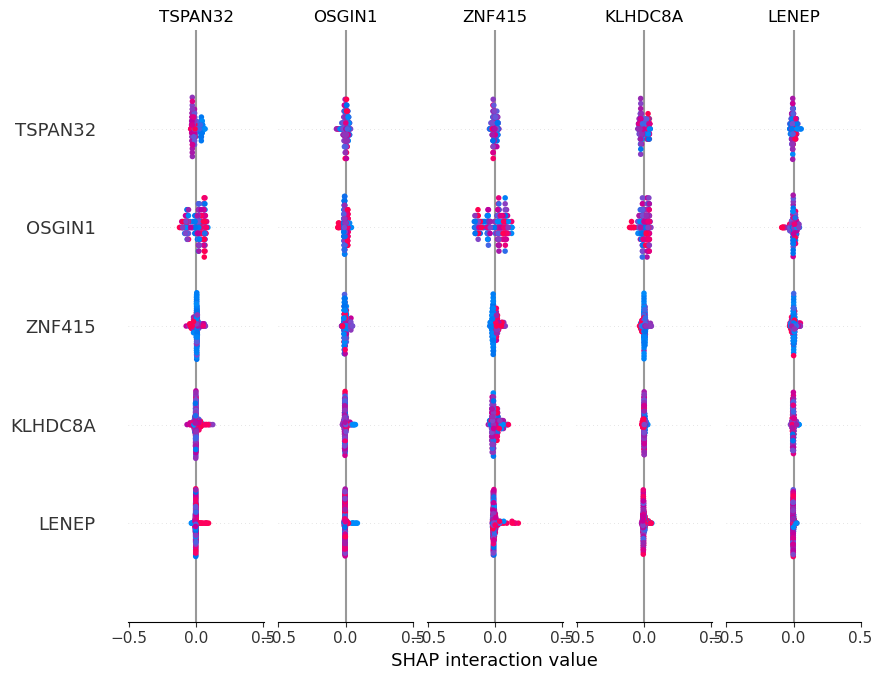

In [32]:
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_final)
shap.summary_plot(shap_values, X_test_final)

In [33]:
def shap_values_to_list(shap_values, model):
    shap_as_list=[]
    for i in range(len(model.classes_)):
        shap_as_list.append(shap_values[:,:,i])
    return shap_as_list

In [34]:
class_names = ("sl", "hgdn", "lgdn", "ehcc", "phcc")

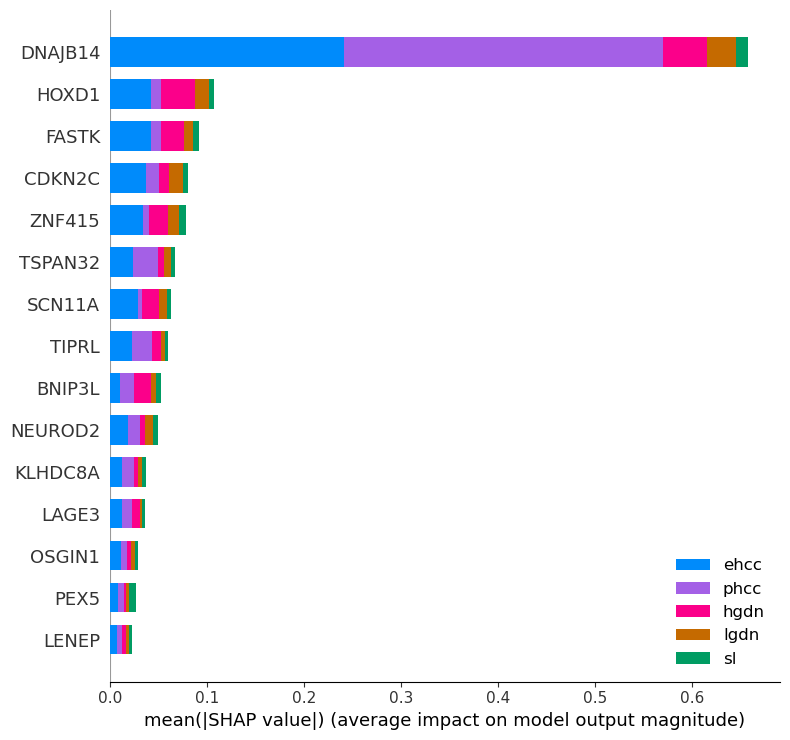

In [35]:
shap_as_list = shap_values_to_list(shap_values, final_model)
shap.summary_plot(shap_as_list, X_test_final, class_names=class_names)